In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
cpa_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/cpa"
chemcpa_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/chemcpa"
id_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/identity"
add_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/additive"
otfm_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/otfm"
emb_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/closest_embedding"
id_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/identity"

In [3]:
model_dirs = {"CPA": cpa_dir, "chemCPA": chemcpa_dir, "otfm": otfm_dir, "add": add_dir, "id": id_dir, "emb": emb_dir}

In [4]:
splits = [1,2,3,4]

# Decoded

In [5]:

all_dfs = []
for split in splits:
    metrics_file = f"ood_metrics_decoded_{split}.csv"
    dfs = {}
    for model, model_dir in model_dirs.items():
        dfs[model] = pd.read_csv(os.path.join(model_dir, metrics_file), index_col=0)
        #dfs[model].loc["sinkhorn_div"] = dfs[model].loc[["sinkhorn_div_1", "sinkhorn_div_10", "sinkhorn_div_100"]].mean(axis=0)
        if "sinkhorn_div_1" in dfs[model].index:
            dfs[model] = dfs[model].drop(["sinkhorn_div_1", "sinkhorn_div_10", "sinkhorn_div_100"])
        if "mmd_distance" in dfs[model].index:
            dfs[model] = dfs[model].drop(["mmd_distance"])
        if "mmd" in dfs[model].index:
            dfs[model] = dfs[model].drop(["mmd"])
        if "e_distance" in dfs[model].index:
            dfs[model] = dfs[model].drop(["e_distance"])
        dfs[model]["model"] = model
    result_df = pd.concat(dfs.values(), ignore_index=False)
    result_df["metric"] = result_df.index
    metrics = result_df["metric"].unique()
    df2 = pd.melt(result_df, id_vars=["model", "metric"])
    df2["split"] = split
    all_dfs.append(df2)

In [6]:
df_ood_metrics_decoded = pd.concat(all_dfs)


In [7]:
df_ood_metrics_decoded[df_ood_metrics_decoded["model"]=="add"].groupby(["split"])["value"].mean()

split
1    0.943985
2    0.898254
3    0.837761
4    0.859008
Name: value, dtype: float64

In [8]:
df_ood_metrics_decoded[df_ood_metrics_decoded["model"]=="CPA"].groupby(["split"])["value"].mean()

split
1    0.962075
2    0.940297
3    0.931946
4    0.953651
Name: value, dtype: float64

In [9]:
df_ood_metrics_decoded[df_ood_metrics_decoded["model"]=="chemCPA"].groupby(["split"])["value"].mean()

split
1    0.967048
2    0.903307
3    0.920254
4    0.965265
Name: value, dtype: float64

In [10]:
df_ood_metrics_decoded[df_ood_metrics_decoded["model"]=="otfm"].groupby(["split"])["value"].mean()

split
1    0.926754
2    0.954994
3    0.957123
4    0.964958
Name: value, dtype: float64

In [11]:
df_ood_metrics_decoded.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/allocation/ood_metrics_decoded.csv")

In [12]:
df_ood_metrics_decoded[df_ood_metrics_decoded["model"]=="emb"].groupby(["split"])["value"].mean()

split
1    0.702621
2    0.803434
3    0.771518
4    0.757240
Name: value, dtype: float64

In [14]:

all_dfs = []
for split in splits:
    metrics_file = f"ood_metrics_encoded_{split}.csv"
    dfs = {}
    for model, model_dir in model_dirs.items():
        dfs[model] = pd.read_csv(os.path.join(model_dir, metrics_file), index_col=0)
        #dfs[model].loc["sinkhorn_div"] = dfs[model].loc[["sinkhorn_div_1", "sinkhorn_div_10", "sinkhorn_div_100"]].mean(axis=0)
        #dfs[model] = dfs[model].drop(["sinkhorn_div_1", "sinkhorn_div_10", "sinkhorn_div_100"])
        dfs[model]["model"] = model
    result_df = pd.concat(dfs.values(), ignore_index=False)
    result_df["metric"] = result_df.index
    metrics = result_df["metric"].unique()
    df2 = pd.melt(result_df, id_vars=["model", "metric"])
    df2["split"] = split
    all_dfs.append(df2)

In [15]:
df_ood_metrics_encoded = pd.concat(all_dfs)


In [16]:
df_ood_metrics_encoded["metric"].value_counts()

metric
r_squared           162
e_distance          162
mmd                 162
sinkhorn_div_1      135
sinkhorn_div_10     135
sinkhorn_div_100    135
Name: count, dtype: int64

In [17]:
df_ood_metrics_encoded.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/allocation/ood_metrics_encoded.csv")

In [18]:

all_dfs = []
for split in splits:
    metrics_file = f"ood_metrics_ood_{split}.csv"
    dfs = {}
    for model, model_dir in model_dirs.items():
        dfs[model] = pd.read_csv(os.path.join(model_dir, metrics_file), index_col=0)
        #dfs[model].loc["sinkhorn_div"] = dfs[model].loc[["sinkhorn_div_1", "sinkhorn_div_10", "sinkhorn_div_100"]].mean(axis=0)
        #dfs[model] = dfs[model].drop(["sinkhorn_div_1", "sinkhorn_div_10", "sinkhorn_div_100"])
        dfs[model]["model"] = model
    result_df = pd.concat(dfs.values(), ignore_index=False)
    result_df["metric"] = result_df.index
    metrics = result_df["metric"].unique()
    df2 = pd.melt(result_df, id_vars=["model", "metric"])
    df2["split"] = split
    all_dfs.append(df2)

In [19]:
df_ood_metrics_deg = pd.concat(all_dfs)


In [20]:
df_ood_metrics_deg

,model,metric,variable,value,split
0,CPA,r_squared,Givinostat+Dasatinib,0.962096,1
1,CPA,sinkhorn_div_1,Givinostat+Dasatinib,117.268394,1
2,CPA,sinkhorn_div_10,Givinostat+Dasatinib,89.176865,1
3,CPA,sinkhorn_div_100,Givinostat+Dasatinib,7.068100,1
4,CPA,e_distance,Givinostat+Dasatinib,6.047985,1
...,...,...,...,...,...
193,id,e_distance,control+SRT2104,5.184864,4
194,id,mmd,control+SRT2104,0.004212,4
195,emb,r_squared,control+SRT2104,0.841063,4
196,emb,e_distance,control+SRT2104,35.605743,4


In [21]:
df_ood_metrics_deg.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/allocation/ood_metrics_deg.csv")

In [43]:
mean_deg = pd.DataFrame(df_ood_metrics_deg[df_ood_metrics_deg["metric"]=='r_squared'].groupby(["model"])["value"].mean())
mean_deg["err"] = 1-mean_deg["value"]
otfm_err = mean_deg.loc["otfm"]["err"]
mean_deg["improvement"] = mean_deg.apply(lambda x: 100* (x["err"]-otfm_err)/otfm_err, axis=1)

In [48]:
mean_dec = pd.DataFrame(df_ood_metrics_decoded[df_ood_metrics_decoded["metric"]=='r_squared'].groupby(["model"])["value"].mean())
mean_dec["err"] = 1-mean_dec["value"]
otfm_err = mean_dec.loc["otfm"]["err"]
mean_dec["improvement"] = mean_dec.apply(lambda x: 100* (x["err"]-otfm_err)/otfm_err, axis=1)

In [45]:
mean_e = pd.DataFrame(df_ood_metrics_encoded[df_ood_metrics_deg["metric"]=='e_distance'].groupby(["model"])["value"].mean())
otfm_err = mean_e.loc["otfm"]["value"]
mean_e["improvement"] = mean_e.apply(lambda x: 100* (x["value"]-otfm_err)/otfm_err, axis=1)

In [39]:
mean_e


,value,improvement
model,,
CPA,50.624560,9.215684
add,105.418360,127.425944
chemCPA,59.231279,27.783524
emb,329.342671,610.512550
id,598.171179,1190.473927
otfm,46.352830,0.000000


In [46]:
mean_deg

,value,err,improvement
model,,,
CPA,0.884918,0.115082,102.143879
add,0.830961,0.169039,196.921440
chemCPA,0.873570,0.126430,122.077193
emb,0.679583,0.320417,462.819962
id,-0.163240,1.163240,1943.257391
otfm,0.943069,0.056931,0.000000


In [49]:
mean_dec

,value,err,improvement
model,,,
CPA,0.946746,0.053254,7.451379
add,0.885705,0.114295,130.612547
chemCPA,0.937995,0.062005,25.108322
emb,0.758758,0.241242,386.755769
id,0.526519,0.473481,855.343879
otfm,0.950439,0.049561,0.000000


<Axes: xlabel='model', ylabel='improvement'>

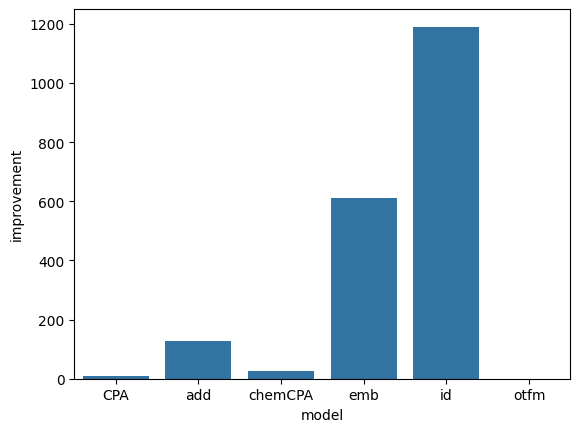

In [52]:
import seaborn as sns
sns.barplot(mean_e, x="model", y="improvement")